In [4]:
import pandas as pd

# Create a dummy DataFrame to demonstrate
data = {
    'temperature': [22, 24, 30, 32, 25, 28],
    'humidity': [40, 42, 70, 75, 50, 60],
}
df = pd.DataFrame(data)

print("Original DataFrame:")
display(df.head())

Original DataFrame:


,temperature,humidity
0,22,40
1,24,42
2,30,70
3,32,75
4,25,50


### K-Means Clustering Example

This example demonstrates how to apply K-Means clustering to the 'temperature' and 'humidity' columns of your DataFrame. We'll use 3 clusters as an example.

Original DataFrame:


,temperature,humidity
0,22,40
1,24,42
2,30,70
3,32,75
4,25,50


DataFrame with cluster assignments:


,temperature,humidity,cluster
0,22,40,1
1,24,42,1
2,30,70,2
3,32,75,2
4,25,50,1


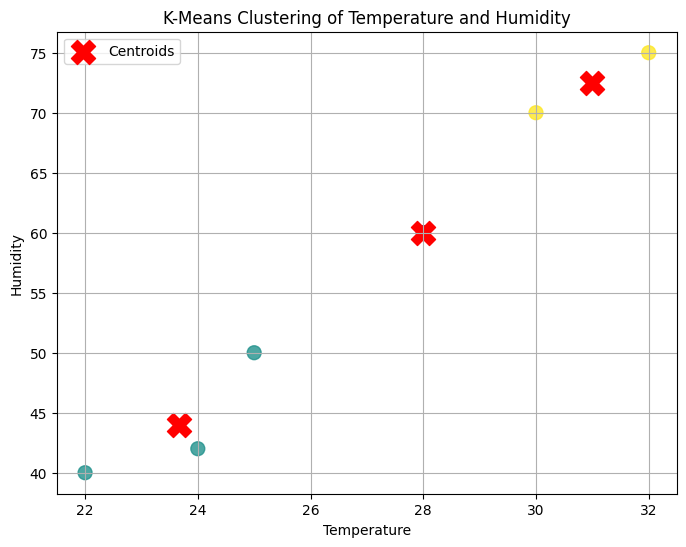

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans


# Create a dummy DataFrame to demonstrate
data = {
    'temperature': [22, 24, 30, 32, 25, 28],
    'humidity': [40, 42, 70, 75, 50, 60],
}
df = pd.DataFrame(data)

print("Original DataFrame:")
display(df.head())
# Prepare the data for clustering (select 'temperature' and 'humidity' columns)
X = df[['temperature', 'humidity']]

# Initialize KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10) # n_init is set to suppress a future warning

# Fit the model and predict the clusters
df['cluster'] = kmeans.fit_predict(X)

print("DataFrame with cluster assignments:")
display(df.head())

plt.figure(figsize=(8, 6))
plt.scatter(df['temperature'], df['humidity'], c=df['cluster'], cmap='viridis', s=100, alpha=0.8)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=300, c='red', marker='X', label='Centroids')
plt.title('K-Means Clustering of Temperature and Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.legend()
plt.grid(True)
plt.show()

Cluster Labels: [1 1 0 0]
Centroids:
 [[31.  72.5]
 [23.  41. ]]


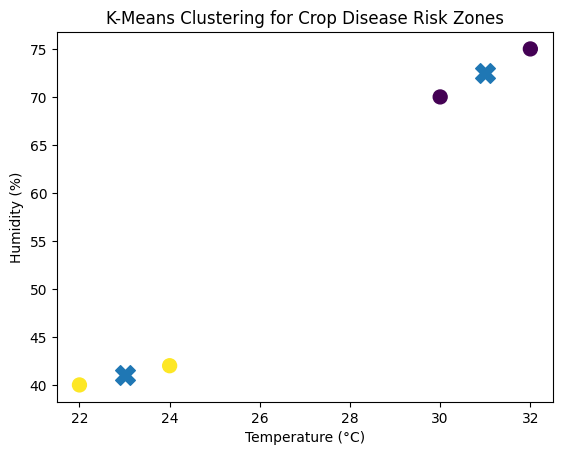

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# Dataset: Temperature and Humidity of farm fields
# [Temperature, Humidity]

data = np.array([
    [22, 40],   # Field P1
    [24, 42],   # Field P2
    [30, 70],   # Field P3
    [32, 75]    # Field P4
])

# Apply K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans.fit(data)

# Cluster labels
labels = kmeans.labels_

# Centroids
centroids = kmeans.cluster_centers_

print("Cluster Labels:", labels)
print("Centroids:\n", centroids)

# Visualization
plt.scatter(data[:,0], data[:,1], c=labels, cmap='viridis', s=100)

# Plot centroids
plt.scatter(centroids[:,0], centroids[:,1], marker='X', s=200)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("K-Means Clustering for Crop Disease Risk Zones")

plt.show()

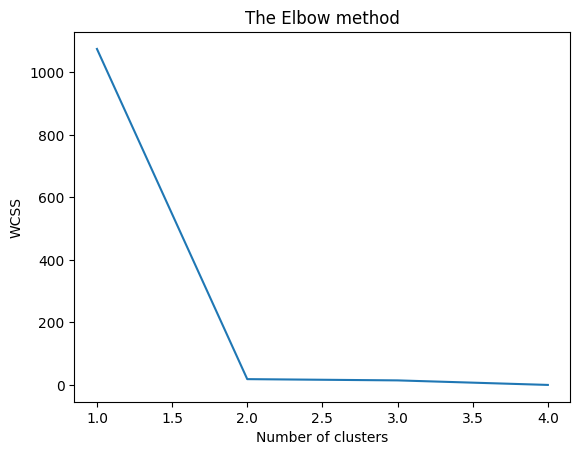

[1074.75, 18.5, 14.5, 0.0]


In [19]:
#Elbow method to find the optimal number of clusters
wcss=[]
for i in range(1, len(data) + 1):
    kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
    kmeans.fit(data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, len(data) + 1),wcss)
plt.title('The Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

print(wcss)

In [20]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score

# 1. Generate X_Train (The 'Offer' feature)
# 4 Spam have it, 2 don't | 1 Not Spam has it, 3 don't
X_Train = np.array([[1], [1], [1], [1], [0], [0], [1], [0], [0], [0]])

# 2. Generate Y_Train (Labels: 1 for Spam, 0 for Not Spam)
Y_Train = np.array([1, 1, 1, 1, 1, 1, 0, 0, 0, 0])

# 3. Initialize and Fit
nb = GaussianNB()
nb.fit(X_Train, Y_Train)

# 4. Define X_Test (A new email containing "Offer")
X_Test = np.array([[1]])
Y_Test = [1] # Assuming the true label for this test is Spam

# 5. Predict and Evaluate
y_pred_nb = nb.predict(X_Test)
cmnb = confusion_matrix(Y_Test, y_pred_nb)
accuracy_nb = accuracy_score(Y_Test, y_pred_nb)

print("Prediction for 'Offer':", "Spam" if y_pred_nb[0] == 1 else "Not Spam")
print("Confusion Matrix:\n", cmnb)
print("Accuracy:", accuracy_nb)

Prediction for 'Offer': Spam
Confusion Matrix:
 [[1]]
Accuracy: 1.0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [21]:
# importing required libraries
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# read the train and test dataset
train_data = pd.read_csv('train-data.csv')
test_data = pd.read_csv('test-data.csv')

# shape of the dataset
print('Shape of training data :',train_data.shape)
print('Shape of testing data :',test_data.shape)

# Now, we need to predict the missing target variable in the test data
# target variable - Survived

# seperate the independent and target variable on training data
train_x = train_data.drop(columns=['Survived'],axis=1)
train_y = train_data['Survived']

# seperate the independent and target variable on testing data
test_x = test_data.drop(columns=['Survived'],axis=1)
test_y = test_data['Survived']

'''
Create the object of the Naive Bayes model
You can also add other parameters and test your code here
Some parameters are : var_smoothing
Documentation of sklearn GaussianNB:

https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html

 '''
model = GaussianNB()

# fit the model with the training data
model.fit(train_x,train_y)

# predict the target on the train dataset
predict_train = model.predict(train_x)
print('Target on train data',predict_train)

# Accuray Score on train dataset
accuracy_train = accuracy_score(train_y,predict_train)
print('accuracy_score on train dataset : ', accuracy_train)

# predict the target on the test dataset
predict_test = model.predict(test_x)
print('Target on test data',predict_test)

# Accuracy Score on test dataset
accuracy_test = accuracy_score(test_y,predict_test)
print('accuracy_score on test dataset : ', accuracy_test)

FileNotFoundError: [Errno 2] No such file or directory: 'train-data.csv'